In [ ]:
%pip install pandas numpy matplotlib seaborn scipy

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)
pd.set_option("display.max_columns", None)

In [ ]:
df = pd.read_csv("weatherAUS.csv")
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [ ]:
print("Dimensi data:", df.shape)
print("\nTipedata:")
print(df.dtypes)

print("\nInfo umum:")
df.info()

print("\nStatistik deskriptif (numerik):")
df.describe

print("\nStatistik deskriptif (kategorikal):")
df.describe(include="object")

# Cek missing value
print(df.isnull().sum())
print("\nTotal baris dengan minimal 1 missing value:", df.isnull().any(axis=1).sum())

#Cek duplikasi baris
print("Duplikat (termasuk, salah):", df.duplicated(["Date", "Location"]).sum())

#Cek inkonsistensi kolom kategorikal
print("Nilai unik pada 'Location':", df["Location"].dropna().unique())
print("Jumlah variasi:", df["Location"].dropna().nunique())
print("Nilai unik pada 'WindGustDir':", df["WindGustDir"].dropna().unique())
print("Jumlah variasi:", df["WindGustDir"].dropna().nunique())
print("Nilai unik pada 'WindDir9am':", df["WindDir9am"].dropna().unique())
print("Jumlah variasi:", df["WindDir9am"].dropna().nunique())
print("Nilai unik pada 'WindDir3pm':", df["WindDir3pm"].dropna().unique())
print("Jumlah variasi:", df["WindDir3pm"].dropna().nunique())
print("Nilai unik pada 'RainToday':", df["RainToday"].dropna().unique())
print("Jumlah variasi:", df["RainToday"].dropna().nunique())
print("Nilai unik pada 'RainTomorrow':", df["RainTomorrow"].dropna().unique())
print("Jumlah variasi:", df["RainTomorrow"].dropna().nunique())

#Cek rentang nilai wajar secara fisik untuk tiap fitur numerik
numeric_cols = ["MinTemp","MaxTemp","Rainfall","Evaporation","Sunshine",
                "WindGustSpeed", "WindSpeed9am","WindSpeed3pm","Humidity9am",
                "Humidity3pm","Pressure9am","Pressure3pm","Cloud9am","Cloud3pm",
                "Temp9am","Temp3pm"]
print(df[numeric_cols].describe())

Dimensi data: (145460, 23)

Tipedata:
Date              object
Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed    float64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
RainTomorrow      object
dtype: object

Info umum:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        14419

In [ ]:
valid_ranges = {
    "MinTemp": (-15, 50),       # Derajat Celcius (Suhu ekstrem dingin dan panas di Australia)
    "MaxTemp": (-10, 60),       # Derajat Celcius
    "Rainfall": (0, 400),       # mm (Rentang 0-40 mm umum, tapi badai bisa mencapai 370+ mm)
    "Evaporation": (0, 40),     # mm (Di atas 40 mm per hari biasanya adalah error pencatatan)
    "Sunshine": (0, 15),        # Jam (Maksimal durasi matahari bersinar sehari ~14.5 jam)
    "WindGustSpeed": (0, 150),  # km/jam (Batas aman untuk mencakup angin topan/badai)
    "WindSpeed9am": (0, 100),   # km/jam
    "WindSpeed3pm": (0, 100),   # km/jam
    "Humidity9am": (0, 100),    # Persentase (%) mutlak antara 0 hingga 100
    "Humidity3pm": (0, 100),    # Persentase (%) mutlak antara 0 hingga 100
    "Pressure9am": (970, 1050), # hPa (Tekanan udara normal permukaan laut adalah ~1013 hPa)
    "Pressure3pm": (970, 1050), # hPa
    "Cloud9am": (0, 9),         # Skala Okta (0 = cerah, 8 = mendung total, 9 = terhalang kabut)
    "Cloud3pm": (0, 9),         # Skala Okta
    "Temp9am": (-15, 50),       # Derajat Celcius
    "Temp3pm": (-10, 50),       # Derajat Celcius
}

for col, (low, high) in valid_ranges.items():
  n_invalid = ((df[col]<low)|(df[col]>high)).sum()
  print(f"{col}: {n_invalid} nilai di luar rentang wajar ({low}-{high})")
  df.loc[(df[col]<low) | (df[col] > high), col] = np.nan

MinTemp: 0 nilai di luar rentang wajar (-15-50)
MaxTemp: 0 nilai di luar rentang wajar (-10-60)
Rainfall: 0 nilai di luar rentang wajar (0-400)
Evaporation: 96 nilai di luar rentang wajar (0-40)
Sunshine: 0 nilai di luar rentang wajar (0-15)
WindGustSpeed: 0 nilai di luar rentang wajar (0-150)
WindSpeed9am: 1 nilai di luar rentang wajar (0-100)
WindSpeed3pm: 0 nilai di luar rentang wajar (0-100)
Humidity9am: 0 nilai di luar rentang wajar (0-100)
Humidity3pm: 0 nilai di luar rentang wajar (0-100)
Pressure9am: 0 nilai di luar rentang wajar (970-1050)
Pressure3pm: 0 nilai di luar rentang wajar (970-1050)
Cloud9am: 0 nilai di luar rentang wajar (0-9)
Cloud3pm: 0 nilai di luar rentang wajar (0-9)
Temp9am: 0 nilai di luar rentang wajar (-15-50)
Temp3pm: 0 nilai di luar rentang wajar (-10-50)


In [ ]:
print("Missing value sebelum imputasi:\n", df.isnull().sum())

# 1. Drop missing value pada target prediksi (RainTomorrow)
df.dropna(subset=['RainTomorrow'], inplace=True)

# 2. Imputasi Numerik dengan Median (Robust terhadap outlier)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# 3. Imputasi RainToday berdasarkan kolom Rainfall yang sudah terisi (Logis meteorologi)
df['RainToday'] = np.where(df['Rainfall'] > 1.0, 'Yes', 'No')

# 4. Imputasi kolom Kategorikal dengan Modus
categorical_cols = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing value setelah imputasi:\n", df.isnull().sum())

Missing value sebelum imputasi:
 Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62886
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1768
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64

Missing value setelah imputasi:
 Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm    

In [ ]:
assert df.isnull().sum().sum() == 0, "Masih ada missing value!"
assert df.duplicated(["Date","Location"]).sum() == 0, "Masih ada duplikat!"
print("Data sudah bersih dan siap untuk tahap selection & Transformation.")

Data sudah bersih dan siap untuk tahap selection & Transformation.


In [ ]:
# Kolom identifier
id_cols = ["Date", "Location"]

# Fitur numerik (sensor)
numeric_cols = [
    "MinTemp","MaxTemp","Rainfall","Evaporation","Sunshine",
    "WindGustSpeed", "WindSpeed9am","WindSpeed3pm","Humidity9am",
    "Humidity3pm","Pressure9am","Pressure3pm","Cloud9am","Cloud3pm",
    "Temp9am","Temp3pm"
]

# Fitur kategorikal
categorical_cols = ["WindGustDir","WindDir9am","WindDir3pm","RainToday","Location"]

# Target (SUDAH BERBENTUK LIST)
target_col = ["RainTomorrow"]

# PERBAIKAN: Hapus kurung siku pada target_col
df_selected = df[numeric_cols + categorical_cols + target_col].copy()

df_selected.head()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,WindGustDir,WindDir9am,WindDir3pm,RainToday,Location,RainTomorrow
0,13.4,22.9,0.6,4.8,8.5,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8,W,W,WNW,No,Albury,No
1,7.4,25.1,0.0,4.8,8.5,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,5.0,5.0,17.2,24.3,WNW,NNW,WSW,No,Albury,No
2,12.9,25.7,0.0,4.8,8.5,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,5.0,2.0,21.0,23.2,WSW,W,WSW,No,Albury,No
3,9.2,28.0,0.0,4.8,8.5,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,5.0,5.0,18.1,26.5,NE,SE,E,No,Albury,No
4,17.5,32.3,1.0,4.8,8.5,41.0,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,W,ENE,NW,No,Albury,No


In [ ]:
import pandas as pd

# 1. Encoding data Yes/No menjadi 1/0
df_selected['RainToday'] = df_selected['RainToday'].map({'No': 0, 'Yes': 1})
df_selected['RainTomorrow'] = df_selected['RainTomorrow'].map({'No': 0, 'Yes': 1})

# 2. One-Hot Encoding untuk Location dan Arah Angin
# Tentukan kolom apa saja yang mau dipecah
cat_to_encode = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']

# Proses One-Hot Encoding menggunakan pandas get_dummies
df_encoded = pd.get_dummies(df_selected, columns=cat_to_encode, drop_first=True)

# Tampilkan hasilnya
print("Ukuran data setelah di-encode:", df_encoded.shape)
df_encoded.head()

Ukuran data setelah di-encode: (142193, 111)


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Location_Albany,Location_Albury,Location_AliceSprings,Location_BadgerysCreek,Location_Ballarat,Location_Bendigo,Location_Brisbane,Location_Cairns,Location_Canberra,Location_Cobar,Location_CoffsHarbour,Location_Dartmoor,Location_Darwin,Location_GoldCoast,Location_Hobart,Location_Katherine,Location_Launceston,Location_Melbourne,Location_MelbourneAirport,Location_Mildura,Location_Moree,Location_MountGambier,Location_MountGinini,Location_Newcastle,Location_Nhil,Location_NorahHead,Location_NorfolkIsland,Location_Nuriootpa,Location_PearceRAAF,Location_Penrith,Location_Perth,Location_PerthAirport,Location_Portland,Location_Richmond,Location_Sale,Location_SalmonGums,Location_Sydney,Location_SydneyAirport,Location_Townsville,Location_Tuggeranong,Location_Uluru,Location_WaggaWagga,Location_Walpole,Location_Watsonia,Location_Williamtown,Location_Witchcliffe,Location_Wollongong,Location_Woomera,WindGustDir_ENE,WindGustDir_ESE,WindGustDir_N,WindGustDir_NE,WindGustDir_NNE,WindGustDir_NNW,WindGustDir_NW,WindGustDir_S,WindGustDir_SE,WindGustDir_SSE,WindGustDir_SSW,WindGustDir_SW,WindGustDir_W,WindGustDir_WNW,WindGustDir_WSW,WindDir9am_ENE,WindDir9am_ESE,WindDir9am_N,WindDir9am_NE,WindDir9am_NNE,WindDir9am_NNW,WindDir9am_NW,WindDir9am_S,WindDir9am_SE,WindDir9am_SSE,WindDir9am_SSW,WindDir9am_SW,WindDir9am_W,WindDir9am_WNW,WindDir9am_WSW,WindDir3pm_ENE,WindDir3pm_ESE,WindDir3pm_N,WindDir3pm_NE,WindDir3pm_NNE,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW
0,13.4,22.9,0.6,4.8,8.5,44.0,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8,0,0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,7.4,25.1,0.0,4.8,8.5,44.0,4.0,22.0,44.0,25.0,1010.6,1007.8,5.0,5.0,17.2,24.3,0,0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,12.9,25.7,0.0,4.8,8.5,46.0,19.0,26.0,38.0,30.0,1007.6,1008.7,5.0,2.0,21.0,23.2,0,0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
3,9.2,28.0,0.0,4.8,8.5,24.0,11.0,9.0,45.0,16.0,1017.6,1012.8,5.0,5.0,18.1,26.5,0,0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fal

In [ ]:
sns.set_theme(style="whitegrid")

# Copy dataframe agar data asli aman
df_vis = df.copy()

# Encode Target menjadi angka (0 dan 1) khusus untuk cek korelasi
df_vis['RainTomorrow_Num'] = df_vis['RainTomorrow'].map({'No': 0, 'Yes': 1})
df_vis['RainToday_Num'] = df_vis['RainToday'].map({'No': 0, 'Yes': 1})

In [ ]:
# Cek persentase outlier untuk SEMUA fitur numerik sekaligus
num_cols = df_vis.select_dtypes(include=['float64', 'int64']).columns
# Buang kolom target numerik jika ada di df_vis
num_cols = [col for col in num_cols if 'RainTomorrow' not in col and 'RainToday' not in col]

outlier_summary = []

for col in num_cols:
    valid_data = df_vis[col].dropna()
    n_valid = len(valid_data)

    q1 = valid_data.quantile(0.25)
    q3 = valid_data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    n_outliers = ((valid_data < lower_bound) | (valid_data > upper_bound)).sum()
    outlier_pct = (n_outliers / n_valid) * 100

    outlier_summary.append({
        'Fitur': col,
        'Outlier (%)': round(outlier_pct, 2),
        'Jumlah Outlier': n_outliers,
        'Total Data Valid': n_valid
    })

# Tampilkan dalam bentuk tabel terurut dari persentase terbesar
df_outlier_table = pd.DataFrame(outlier_summary).sort_values(by='Outlier (%)', ascending=False)
df_outlier_table.reset_index(drop=True, inplace=True)
df_outlier_table

,Fitur,Outlier (%),Jumlah Outlier,Total Data Valid
0,Sunshine,42.77,60823,142193
1,Evaporation,22.66,32224,142193
2,Rainfall,20.07,28545,142193
3,WindGustSpeed,3.79,5386,142193
4,Cloud3pm,3.49,4957,142193
5,Pressure9am,1.90,2708,142193
6,WindSpeed3pm,1.73,2458,142193
7,Pressure3pm,1.62,2305,142193
8,WindSpeed9am,1.22,1738,142193
9,Humidity9am,1.00,1419,142193


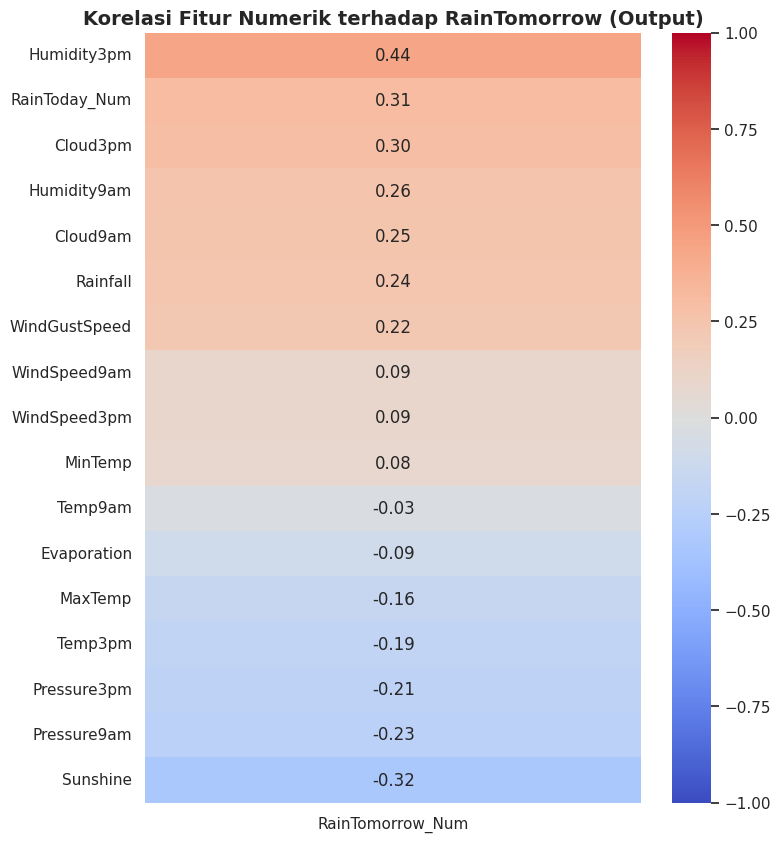

In [ ]:
# Memilih hanya kolom numerik + target numerik
num_cols_for_corr = df_vis.select_dtypes(include=['float64', 'int64']).columns

# Menghitung matriks korelasi
corr_matrix = df_vis[num_cols_for_corr].corr()

# Mengambil korelasi khusus terhadap target (RainTomorrow_Num)
target_corr = corr_matrix[['RainTomorrow_Num']].sort_values(by='RainTomorrow_Num', ascending=False)
target_corr = target_corr.drop('RainTomorrow_Num') # Hapus korelasi target dgn dirinya sendiri

# Visualisasi Korelasi dengan Target
plt.figure(figsize=(8, 10))
sns.heatmap(target_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", cbar=True)
plt.title('Korelasi Fitur Numerik terhadap RainTomorrow (Output)', fontsize=14, fontweight='bold')
plt.show()

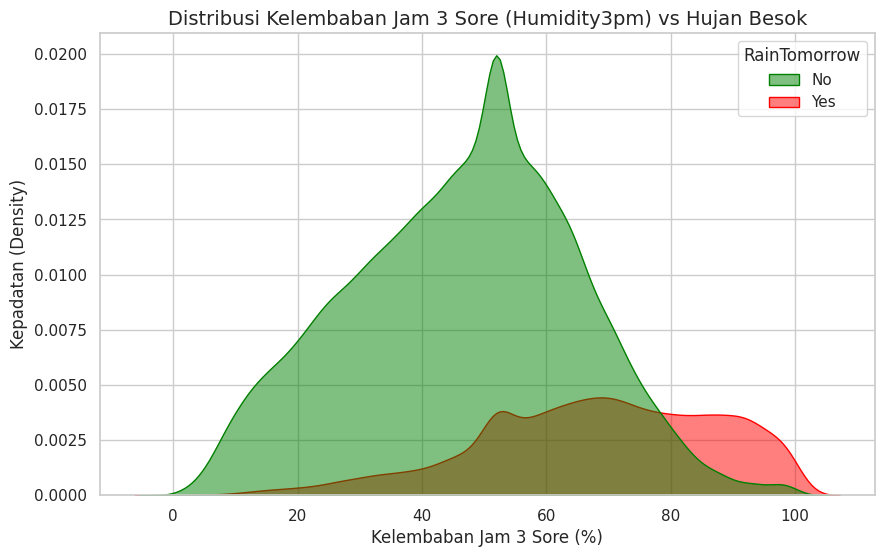

In [ ]:
# Visualisasi Density (KDE) untuk Humidity3pm (Fitur dengan korelasi positif terkuat)
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_vis, x='Humidity3pm', hue='RainTomorrow', fill=True, palette=['green', 'red'], alpha=0.5)
plt.title('Distribusi Kelembaban Jam 3 Sore (Humidity3pm) vs Hujan Besok', fontsize=14)
plt.xlabel('Kelembaban Jam 3 Sore (%)')
plt.ylabel('Kepadatan (Density)')
plt.show()

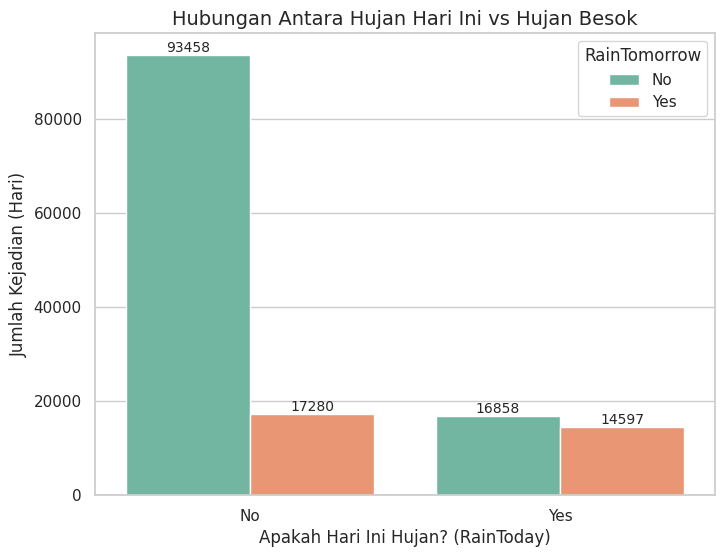

In [ ]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df_vis, x='RainToday', hue='RainTomorrow', palette='Set2')
plt.title('Hubungan Antara Hujan Hari Ini vs Hujan Besok', fontsize=14)
plt.xlabel('Apakah Hari Ini Hujan? (RainToday)')
plt.ylabel('Jumlah Kejadian (Hari)')

# Menambahkan persentase di atas bar
for p in ax.patches:
    height = p.get_height()
    if height > 0: # Handle missing NaN bars
        ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10)

plt.show()

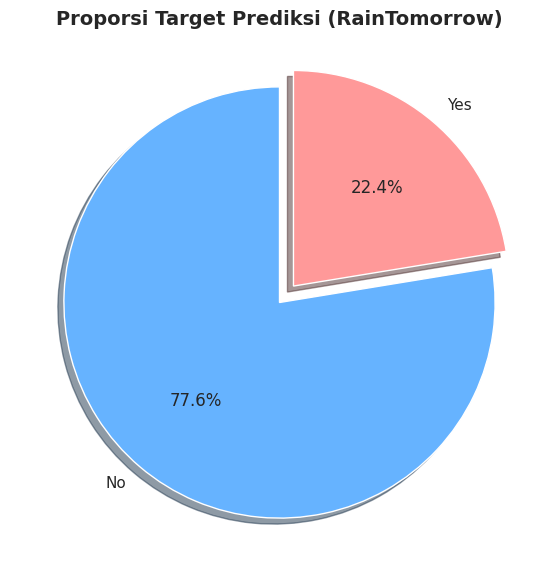

In [ ]:
# Cell 7: Visualisasi Proporsi Target (RainTomorrow)
plt.figure(figsize=(7, 7))

# Menghitung jumlah masing-masing kelas
target_counts = df['RainTomorrow'].value_counts()

# Membuat Pie Chart
plt.pie(target_counts, labels=target_counts.index, autopct='%1.1f%%',
        startangle=90, colors=['#66b3ff', '#ff9999'], explode=(0, 0.1), shadow=True)

plt.title('Proporsi Target Prediksi (RainTomorrow)', fontsize=14, fontweight='bold')
plt.show()

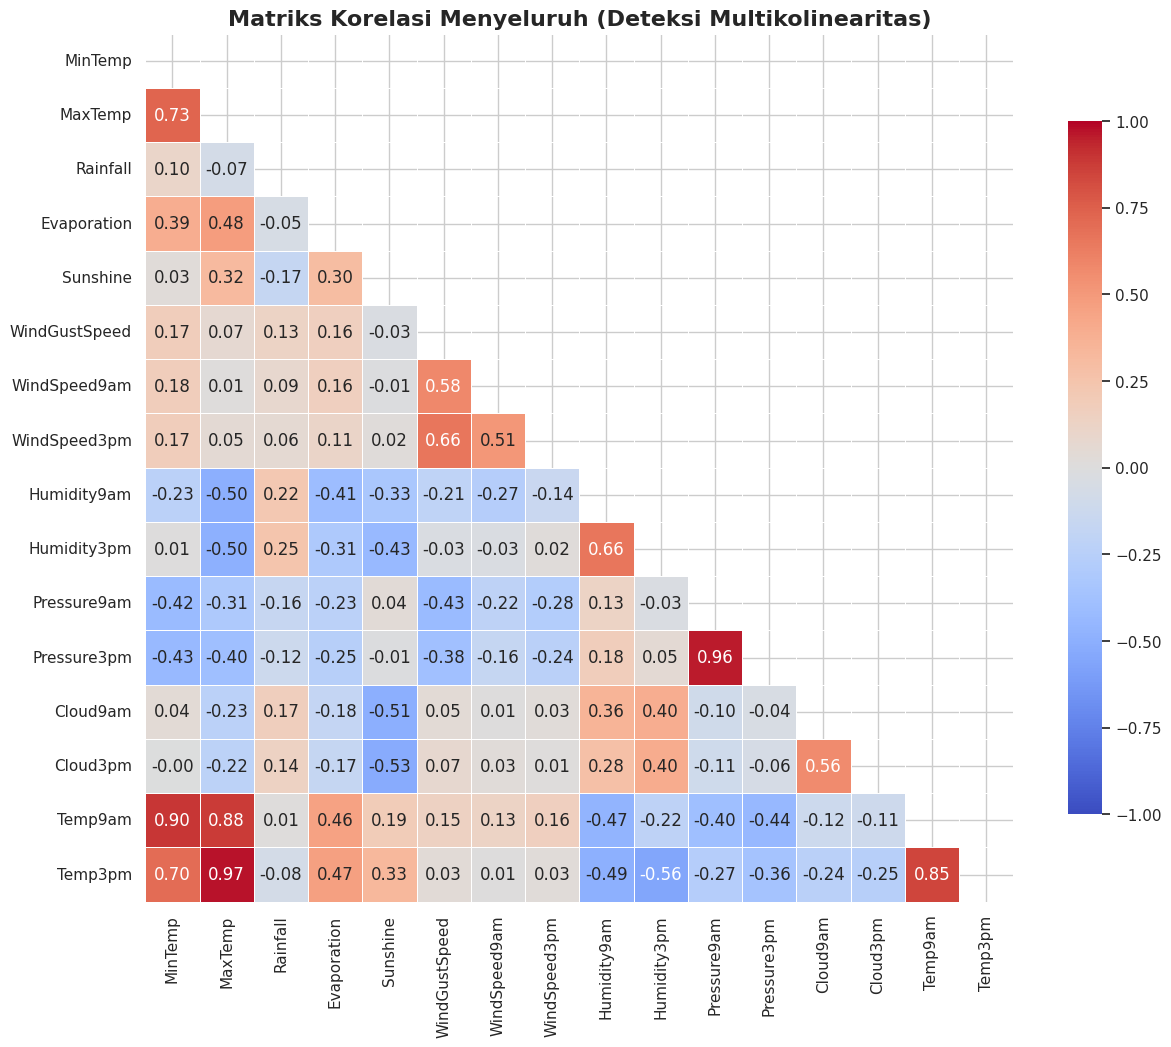

In [ ]:
# Cell 8: Matriks Korelasi Antar Semua Fitur Numerik
plt.figure(figsize=(14, 12))

# Mengambil fitur numerik saja
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_all = df[num_cols].corr()

# Membuat Heatmap setengah (agar lebih mudah dibaca)
mask = np.triu(np.ones_like(corr_all, dtype=bool))

sns.heatmap(corr_all, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .75})

plt.title('Matriks Korelasi Menyeluruh (Deteksi Multikolinearitas)', fontsize=16, fontweight='bold')
plt.show()

In [ ]:
# Menghapus fitur yang mengalami Multikolinearitas tinggi
kolom_dihapus = ['Pressure9am', 'Temp9am', 'Temp3pm']

# Menggunakan inplace=True agar dataframe langsung diperbarui
df.drop(columns=kolom_dihapus, inplace=True)

# Mengecek ukuran data setelah penghapusan
print("Sisa kolom setelah seleksi fitur:", df.shape[1], "kolom")
print("\nDaftar kolom saat ini:")
print(df.columns.tolist())

Sisa kolom setelah seleksi fitur: 20 kolom

Daftar kolom saat ini:
['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'RainToday', 'RainTomorrow']


In [ ]:
# Simpan data yang sudah bersih ke format CSV baru
df.to_csv('weatherAUS_cleaned.csv', index=False)
print("Data bersih berhasil disimpan sebagai 'weatherAUS_cleaned.csv'")

from google.colab import files
files.download('weatherAUS_cleaned.csv')

Data bersih berhasil disimpan sebagai 'weatherAUS_cleaned.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>